In [2]:
import pandas as pd
import os

import chunkbench.path_utils as pu

# Don't trim the content of each cell
pd.set_option("display.max_colwidth", None)

runs_df = pu.RunLocator.get_runs_df()
runs_df = runs_df[runs_df['trace_path'].str.contains('meaninterarrivals')]

runs_df['pct_heavy'] = runs_df['trace_path'].apply(lambda x: int(x.split('pctheavy')[0][-2:]))
runs_df['mean_interarrival_s'] = runs_df['trace_path'].apply(lambda x: float(x.split('meaninterarrivals')[0].split('_')[-1]))

runs_df.tail()

,aws_account_id,aws_region,conn_info_path,endpoint_name,maxconns,num_queries,run_dir,run_id,schema_name,tpcds_scale_factor,trace_path,pct_heavy,mean_interarrival_s
75,941474060611,us-east-1,/home/markakis/chunkbench/config/conn.yml,8,1000,335,/home/markakis/chunkbench/data/runs/1760724768,1760724768,ext_tpcds1000,1000,/home/markakis/chunkbench/data/chunk_traces/tpcds_99templates_50pctheavy_10meaninterarrivals.parquet,50,10.0
76,941474060611,us-east-1,/home/markakis/chunkbench/config/conn.yml,4,1000,25,/home/markakis/chunkbench/data/runs/1760732132,1760732132,ext_tpcds1000,1000,/home/markakis/chunkbench/data/chunk_traces/tpcds_99templates_50pctheavy_120meaninterarrivals.parquet,50,120.0
77,941474060611,us-east-1,/home/markakis/chunkbench/config/conn.yml,4,1000,54,/home/markakis/chunkbench/data/runs/1760737903,1760737903,ext_tpcds1000,1000,/home/markakis/chunkbench/data/chunk_traces/tpcds_99templates_50pctheavy_60meaninterarrivals.parquet,50,60.0
78,941474060611,us-east-1,/home/markakis/chunkbench/config/conn.yml,4,1000,114,/home/markakis/chunkbench/data/runs/1760745360,1760745360,ext_tpcds1000,1000,/home/markakis/chunkbench/data/chunk_traces/tpcds_99templates_50pctheavy_30meaninterarrivals.parquet,50,30.0
79,941474060611,us-east-1,/home/markakis/chunkbench/config/conn.yml,4,1000,335,/home/markakis/chunkbench/data/runs/1760755368,1760755368,ext_tpcds1000,1000,/home/markakis/chunkbench/data/chunk_traces/tpcds_99templates_50pctheavy_10meaninterarrivals.parquet,50,10.0


In [3]:
from datetime import datetime


def calculate_concurrency_level_timeseries(filepath: str):

    # Read the text log file. Each row contains a timestamp in this format: 2025-10-03 14:04:31,867
    # Append it to a list
    records = []
    with open(filepath, "r") as f:
        for line in f:
            if "Starting query" in line:
                records.append(
                    {
                        "timestamp": datetime.strptime(
                            line.split(" - ")[0], "%Y-%m-%d %H:%M:%S,%f"
                        ),
                        "event_type": "start",
                        "query_id": line.strip().split(" ")[-1],
                        "duration_s": None
                    }
                )
            elif "finished after" in line:
                records.append(
                    {
                        "timestamp": datetime.strptime(
                            line.split(" - ")[0], "%Y-%m-%d %H:%M:%S,%f"
                        ),
                        "event_type": "end",
                        "query_id": line.split(" ")[6],
                        "duration_s": float(line.strip().split(" ")[-1][2:-1]),
                    }
                )


    df = pd.DataFrame(records)
    df['num_active_after_event'] = df['event_type'].apply(lambda x: 1 if x == 'start' else -1).cumsum()
    df['relative_time_s'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
    return df


df = calculate_concurrency_level_timeseries('/home/markakis/chunkbench/data/runs/1759493397/run.log')

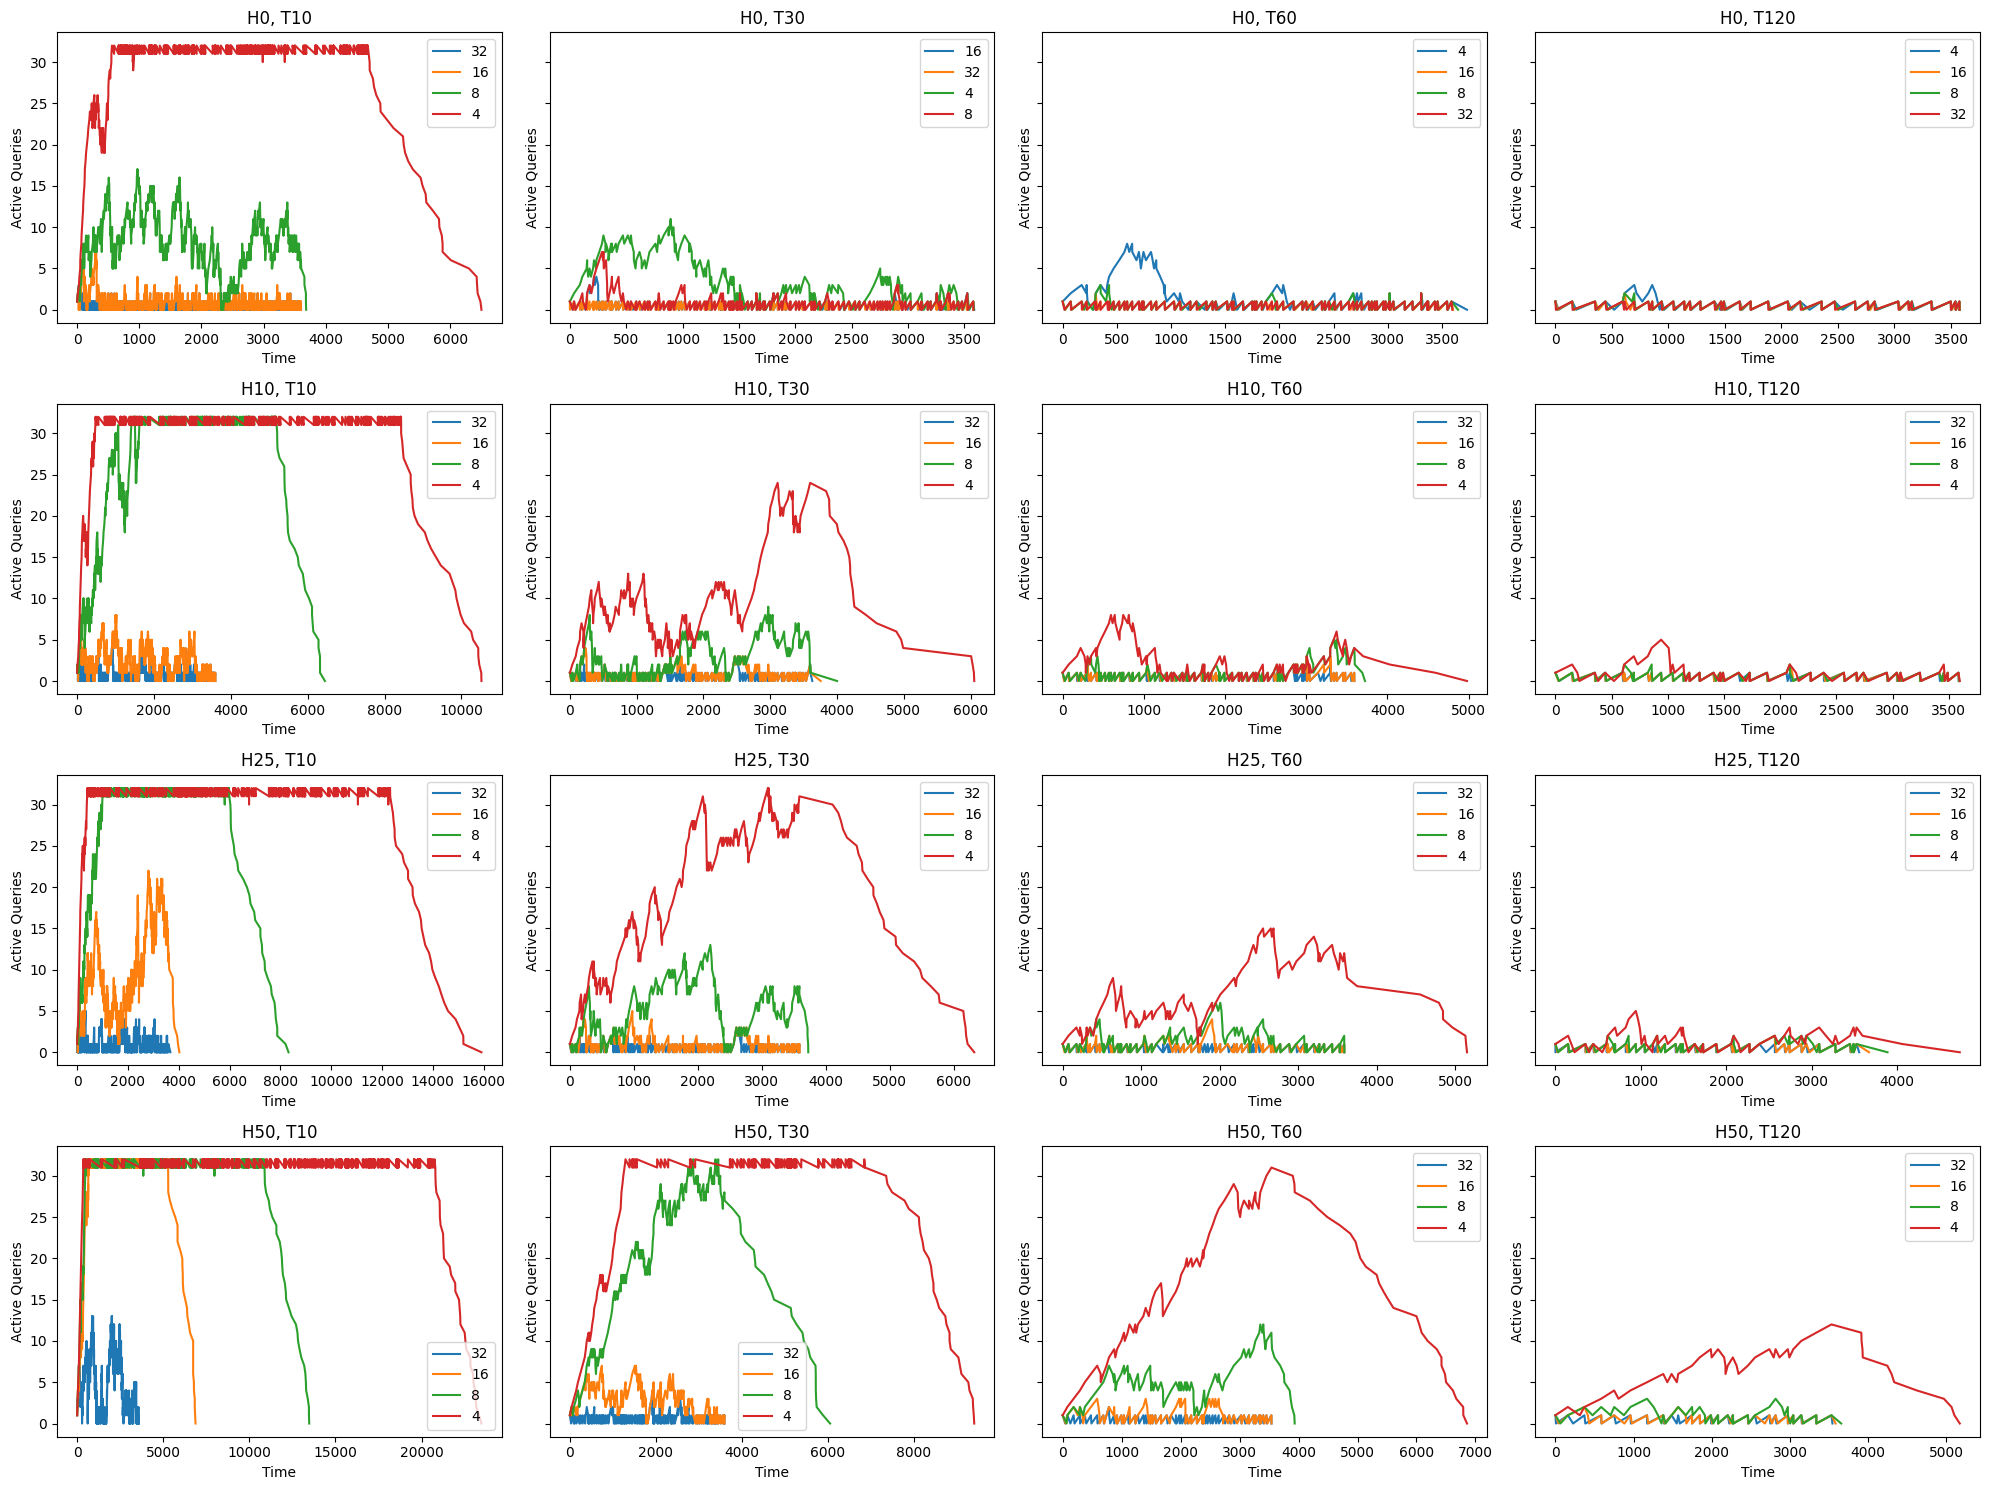

In [5]:
import matplotlib.pyplot as plt


unique_pct_heavy = [0, 10, 25, 50]
unique_mean_interarrival_s =  [10, 30, 60, 120]

fig, ax = plt.subplots(len(unique_pct_heavy), len(unique_mean_interarrival_s), figsize=(20, 15), sharey=True)

for i, pct_heavy in enumerate(unique_pct_heavy):
    for j, mean_interarrival_s in enumerate(unique_mean_interarrival_s):
        run_subset = runs_df[(runs_df['pct_heavy'] == pct_heavy) & (runs_df['mean_interarrival_s'] == mean_interarrival_s)]
     
        for _, row in run_subset.iterrows():
            run_id = row['run_id']
            endpoint_name = row['endpoint_name']
            log_path = os.path.join(pu.DATA_PATH, 'runs', str(run_id), 'run.log')
            df = calculate_concurrency_level_timeseries(log_path)
            ax[i, j].plot(df['relative_time_s'], df['num_active_after_event'], label=endpoint_name)
            ax[i, j].set_title(f'H{pct_heavy}, T{mean_interarrival_s}')
            ax[i, j].set_xlabel('Time')
            ax[i, j].set_ylabel('Active Queries')
            ax[i, j].legend()

plt.tight_layout()
plt.show()

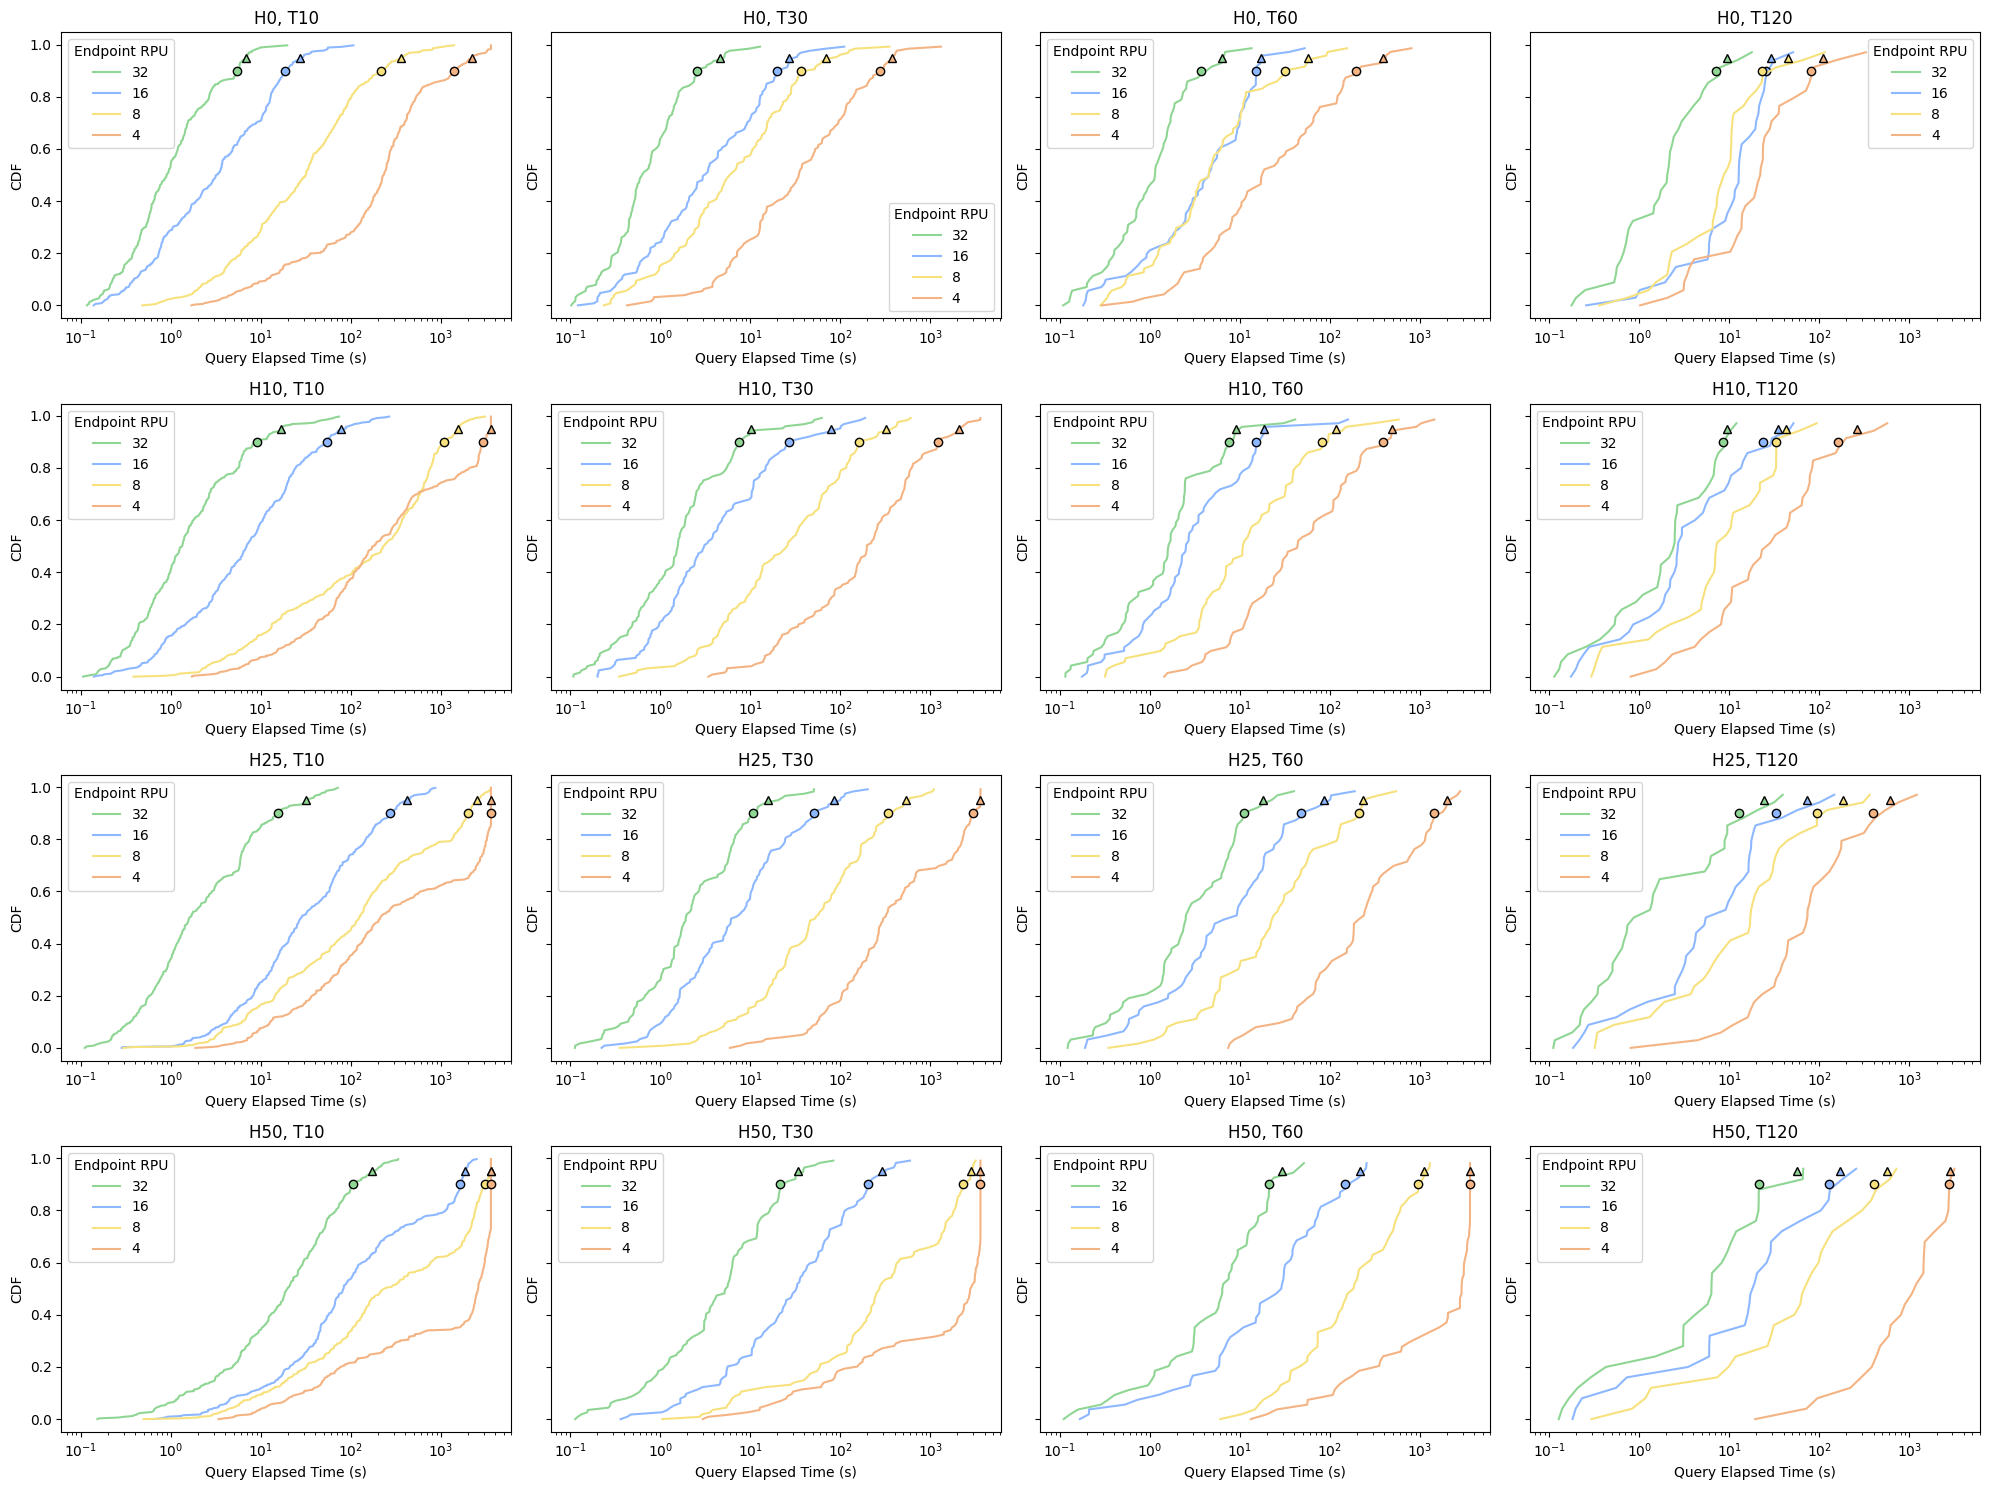

In [7]:
import numpy as np
from chunkbench.generation.chunk import Chunk

fig, axs = plt.subplots(
    len(unique_pct_heavy),
    len(unique_mean_interarrival_s),
    figsize=(20, 15),
    sharey=True,
    sharex=True,
)

endpoint_colors = {
    32: "#8FD694",  # soft green
    16: "#8DB8FF",  # light blue
    8: "#F7E17D",  # soft yellow
    4: "#F4B383",  # warm peach/orange
}


for i, pct_heavy in enumerate(unique_pct_heavy):
    for j, mean_interarrival_s in enumerate(unique_mean_interarrival_s):
        for endpoint in endpoint_colors.keys():
            endpoint_name = str(endpoint)
            run_id = Chunk(H=pct_heavy, T=mean_interarrival_s).get_run_id_on(endpoint_name)
            color = endpoint_colors.get(int(float(endpoint_name)), None)

            sys_query_history_path = os.path.join(
                pu.DATA_PATH, "runs", str(run_id), "sys_query_history.parquet"
            )
            df = pd.read_parquet(sys_query_history_path)

            # Plot a CDF of `elapsed_time` after converting from microseconds to seconds.
            df["elapsed_time_s"] = df["elapsed_time"] / 1e6
            elapsed_time_sorted = np.sort(df["elapsed_time_s"])

            cdf = np.arange(len(elapsed_time_sorted)) / float(len(elapsed_time_sorted))
            axs[i, j].plot(elapsed_time_sorted, cdf, label=f"{endpoint_name}", color=color)

            # Place a marker at the 90th and 95th percentiles
            p90 = np.percentile(df["elapsed_time_s"], 90)
            p95 = np.percentile(df["elapsed_time_s"], 95)
            axs[i, j].plot(p90, 0.9, color=color, marker="o", markeredgecolor="black")
            axs[i, j].plot(p95, 0.95, color=color, marker="^", markeredgecolor="black")

        axs[i, j].set_title(f"H{pct_heavy}, T{mean_interarrival_s}")
        axs[i, j].set_xlabel("Query Elapsed Time (s)")
        axs[i, j].set_ylabel("CDF")
        axs[i, j].set_xscale("log")
        axs[i, j].legend(title="Endpoint RPU")


for ax in axs.flat:
    ax.xaxis.set_tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

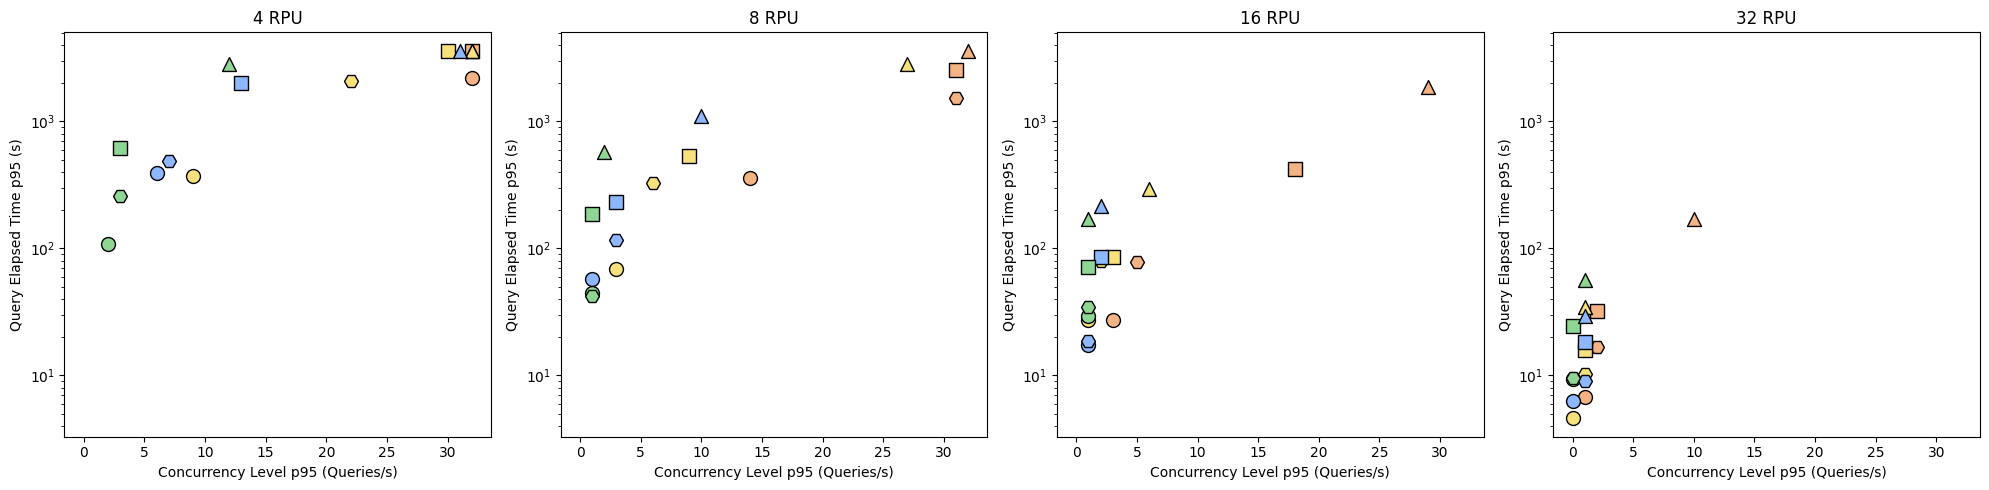

In [45]:
import numpy as np

from chunkbench.generation.composite_workload import Chunk


endpoint_colors = {
    32: "#8FD694",  # soft green
    16: "#8DB8FF",  # light blue
    8: "#F7E17D",  # soft yellow
    4: "#F4B383",  # warm peach/orange
}

fig, axs = plt.subplots(
    1,
    len(endpoint_colors),
    figsize=(20, 5),
    sharey=True,
    sharex=True,
)


for i, (endpoint_rpu, endpoint_color) in enumerate(reversed(endpoint_colors.items())):
    endpoint_name = str(endpoint_rpu)

    for pct_heavy in unique_pct_heavy:
        for mean_interarrival_s in unique_mean_interarrival_s:
            run_subset = runs_df[
                (runs_df["pct_heavy"] == pct_heavy)
                & (runs_df["mean_interarrival_s"] == mean_interarrival_s)
                & (runs_df["endpoint_name"] == endpoint_name)
            ]

            run_id = run_subset["run_id"].iloc[0]

            sys_query_history_path = os.path.join(
                pu.DATA_PATH, "runs", str(run_id), "sys_query_history.parquet"
            )
            df = pd.read_parquet(sys_query_history_path)

            # Plot a point for `elapsed_time` after converting from microseconds to seconds.
            df["elapsed_time_s"] = df["elapsed_time"] / 1e6
            p95 = np.percentile(df["elapsed_time_s"], 95)

            # Calculate the number of concurrent queries at any point in time.
            events = []
            for _, row in df.iterrows():
                events.append((row["start_time"], "start"))
                events.append((row["end_time"], "end"))
            events.sort()

            # Calculate concurrency level time series
            concurrency_level = 0
            concurrency_times = []
            for event_time, event_type in events:
                if event_type == "start":
                    concurrency_level += 1
                else:
                    concurrency_level -= 1
                concurrency_times.append((event_time, concurrency_level))
            concurrency_df = pd.DataFrame(concurrency_times, columns=["interval_start", "concurrency_level"])
            concurrency_df['interval_end'] = concurrency_df['interval_start'].shift(-1)
            concurrency_df['concurrency_level_duration'] = (concurrency_df['interval_end'] - concurrency_df['interval_start']).dt.total_seconds().fillna(0)
            concurrency_df = concurrency_df.sort_values('concurrency_level')

            # Find the p95 concurrency level, weighing by time intervals
            cum = concurrency_df['concurrency_level_duration'].cumsum()
            W = concurrency_df['concurrency_level_duration'].sum()
            p95_concurrency = concurrency_df.loc[cum.ge(0.95 * W), 'concurrency_level'].iloc[0]


            # Retrieve color and shape
            chunk = Chunk(H=pct_heavy, T=mean_interarrival_s)
            axs[i].scatter(
                p95_concurrency,
                p95,
                color=chunk.color(),
                marker=chunk.shape(),
                s=100,
                edgecolor="black",
            )

    axs[i].set_title(f"{endpoint_name} RPU")
    axs[i].set_xlabel("Concurrency Level p95 (Queries/s)")
    axs[i].set_ylabel("Query Elapsed Time p95 (s)")
    axs[i].set_yscale("log")

    axs[i].xaxis.set_tick_params(labelbottom=True)
    axs[i].yaxis.set_tick_params(labelleft=True)


plt.tight_layout()
plt.show()

In [40]:
df

events = []
for _, row in df.iterrows():
    events.append((row["start_time"], "start"))
    events.append((row["end_time"], "end"))
events.sort()

# Calculate concurrency level time series
concurrency_level = 0
concurrency_times = []
for event_time, event_type in events:
    if event_type == "start":
        concurrency_level += 1
    else:
        concurrency_level -= 1
    concurrency_times.append((event_time, concurrency_level))
concurrency_df = pd.DataFrame(concurrency_times, columns=["timestamp", "concurrency_level"])
concurrency_df['concurrency_level_duration'] = -concurrency_df['timestamp'].diff(-1).dt.total_seconds().fillna(0)
concurrency_df['weighted_concurrency'] = concurrency_df['concurrency_level'] * concurrency_df['concurrency_level_duration']
concurrency_df


,timestamp,concurrency_level,concurrency_level_duration,weighted_concurrency
0,2025-10-17 11:31:50.379081,1,6.340679,6.340679
1,2025-10-17 11:31:56.719760,0,152.611948,0.000000
2,2025-10-17 11:34:29.331708,1,66.210894,66.210894
3,2025-10-17 11:35:35.542602,0,145.119431,0.000000
4,2025-10-17 11:38:00.662033,1,11.935049,11.935049
5,2025-10-17 11:38:12.597082,0,202.869342,0.000000
6,2025-10-17 11:41:35.466424,1,3.102813,3.102813
7,2025-10-17 11:41:38.569237,0,162.940057,0.000000
8,2025-10-17 11:44:21.509294,1,21.194000,21.194000
9,2025-10-17 11:44:42.703294,0,186.526948,0.000000


In [41]:
p95_concurrency = concurrency_df['weighted_concurrency'].sum() / concurrency_df['concurrency_level_duration'].sum()
p95_concurrency

np.float64(0.08366937369527978)